# Memo Generation and Retrieval Evaluation

## Project context

This notebook extends the local AI Financial Research Agent prototype. It uses the Phase 0 chunk table and TF-IDF retrieval outputs to create a cited, template-based research memo. No paid APIs, OpenAI API calls, external LLMs, or online services are used.

## Phase 1 objective

Phase 1 adds four local capabilities:

- Retrieve evidence for finance research questions.
- Convert retrieved chunks into citation-style evidence references.
- Extract risk flags with transparent keyword rules.
- Evaluate retrieval coverage, source traceability, and memo grounding.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.config import CHUNKS_DIR, EVIDENCE_DIR, FIGURES_DIR, RETRIEVAL_DIR, REPORTS_DIR
from src.evaluation import (
    build_evaluation_summary,
    evaluate_answer_grounding,
    evaluate_retrieval_coverage,
    evaluate_source_traceability,
    extract_risk_flags,
)
from src.retrieval import create_cited_evidence_table, retrieve_evidence_for_questions
from src.visualization import (
    plot_evidence_count_by_question,
    plot_grounding_check_summary,
    plot_risk_flags_by_category,
    plot_source_traceability_status,
)

for directory in [EVIDENCE_DIR, RETRIEVAL_DIR, FIGURES_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

## Load chunks and evidence tables

The main Phase 1 input is `outputs/chunks/document_chunks.csv`, created in Phase 0. Existing evidence outputs are loaded for reference only; the notebook refreshes research question retrieval outputs below.

In [2]:
chunks_path = CHUNKS_DIR / "document_chunks.csv"
phase0_evidence_path = EVIDENCE_DIR / "evidence_table.csv"
phase0_retrieval_path = RETRIEVAL_DIR / "sample_retrieval_results.csv"

chunks = pd.read_csv(chunks_path)
phase0_evidence = pd.read_csv(phase0_evidence_path) if phase0_evidence_path.exists() else pd.DataFrame()
phase0_retrieval = pd.read_csv(phase0_retrieval_path) if phase0_retrieval_path.exists() else pd.DataFrame()

print(f"Chunks loaded: {chunks.shape[0]} rows from {chunks['document_id'].nunique()} documents")
print(f"Phase 0 evidence rows available: {len(phase0_evidence)}")
chunks.head(3)

Chunks loaded: 13 rows from 6 documents
Phase 0 evidence rows available: 25


,chunk_id,document_id,file_name,title,chunk_index,chunk_text,character_count,word_count
0,bank_profitability_funding_cost__chunk_001,bank_profitability_funding_cost,bank_profitability_funding_cost.txt,Sample Note on Bank Profitability and Funding ...,1,Title: Sample Note on Bank Profitability and F...,600,92
1,bank_profitability_funding_cost__chunk_002,bank_profitability_funding_cost,bank_profitability_funding_cost.txt,Sample Note on Bank Profitability and Funding ...,2,st pressure is higher when customers shift fro...,483,67
2,credit_risk_borrower_behavior__chunk_001,credit_risk_borrower_behavior,credit_risk_borrower_behavior.txt,Sample Note on Credit Risk and Borrower Behavior,1,Title: Sample Note on Credit Risk and Borrower...,600,82


## Define research questions

These questions are designed to cover the core finance themes in the sample document set: lending risk, inflation and rates, payments adoption, profitability, portfolio risk, and management monitoring.

In [3]:
research_questions = [
    "What are the main credit and lending risks?",
    "How do inflation and interest rates affect financial institutions?",
    "What does the corpus say about digital payments adoption?",
    "What affects bank profitability and funding costs?",
    "What market risks affect portfolio performance?",
    "What risks should management monitor?",
]
research_questions

['What are the main credit and lending risks?',
 'How do inflation and interest rates affect financial institutions?',
 'What does the corpus say about digital payments adoption?',
 'What affects bank profitability and funding costs?',
 'What market risks affect portfolio performance?',
 'What risks should management monitor?']

## Retrieve evidence for memo sections

The notebook rebuilds a local TF-IDF index and retrieves the top five chunks for each research question.

In [4]:
retrieval_results = retrieve_evidence_for_questions(chunks, research_questions, top_k=5)
cited_evidence = create_cited_evidence_table(retrieval_results)

retrieval_results.to_csv(RETRIEVAL_DIR / "research_question_retrieval.csv", index=False)
cited_evidence.to_csv(EVIDENCE_DIR / "cited_evidence_table.csv", index=False)

cited_evidence.head(10)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.4.1)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/rovs/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_inst

AttributeError: _ARRAY_API not found

,query,rank,retrieval_score,citation,document_id,title,chunk_id,evidence_snippet
0,What are the main credit and lending risks?,1,0.258072,[FINLEN-CHUNK001],fintech_lending_growth,Sample Note on Fintech Lending Growth,fintech_lending_growth__chunk_001,Title: Sample Note on Fintech Lending Growth D...
1,What are the main credit and lending risks?,2,0.135567,[CRERIS-CHUNK002],credit_risk_borrower_behavior,Sample Note on Credit Risk and Borrower Behavior,credit_risk_borrower_behavior__chunk_002,obability of default. Lenders should monitor d...
2,What are the main credit and lending risks?,3,0.134603,[DIGPAY-CHUNK001],digital_payments_adoption,Sample Note on Digital Payments Adoption,digital_payments_adoption__chunk_001,Title: Sample Note on Digital Payments Adoptio...
3,What are the main credit and lending risks?,4,0.122214,[DIGPAY-CHUNK002],digital_payments_adoption,Sample Note on Digital Payments Adoption,digital_payments_adoption__chunk_002,"chant inactivity, poor dispute handling, and w..."
4,What are the main credit and lending risks?,5,0.113470,[FINLEN-CHUNK002],fintech_lending_growth,Sample Note on Fintech Lending Growth,fintech_lending_growth__chunk_002,rapid customer acquisition without enough rep...
5,How do inflation and interest rates affect fin...,1,0.402405,[INFINT-CHUNK001],inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_001,Title: Sample Note on Inflation and Interest-R...
6,How do inflation and interest rates affect fin...,2,0.210302,[INFINT-CHUNK002],inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk,inflation_interest_rate_risk__chunk_002,"ts bond portfolios. When yields rise, fixed-ra..."
7,How do inflation and interest rates affect fin...,3,0.089204,[BANPRO-CHUNK001],bank_profitability_funding_cost,Sample Note on Bank Profitability and Funding ...,bank_profitability_funding_cost__chunk_001,Title: Sample Note on Bank Profitability and F...
8,How do inflation and interest rates affect fin...,4,0.059121,[DIGPAY-CHUNK002],digital_payments_adoption,Sample Note on Digital Payments Adoption,digital_payments_adoption__chunk_002,"chant inactivity, poor dispute handling, and w..."
9,How do inflation and interest rates affect fin...,5,0.054891,[FINLEN-CHUNK002],fintech_lending_growth,Sample Note on Fintech Lending Growth,fintech_lending_growth__chunk_002,rapid customer acquisition without enough rep...


## Create cited evidence table

Citation IDs are compact references back to document chunks. They are not legal citations; they are traceability markers for this local portfolio prototype.

In [5]:
cited_evidence[["query", "rank", "retrieval_score", "citation", "document_id", "title"]].head(12)

,query,rank,retrieval_score,citation,document_id,title
0,What are the main credit and lending risks?,1,0.258072,[FINLEN-CHUNK001],fintech_lending_growth,Sample Note on Fintech Lending Growth
1,What are the main credit and lending risks?,2,0.135567,[CRERIS-CHUNK002],credit_risk_borrower_behavior,Sample Note on Credit Risk and Borrower Behavior
2,What are the main credit and lending risks?,3,0.134603,[DIGPAY-CHUNK001],digital_payments_adoption,Sample Note on Digital Payments Adoption
3,What are the main credit and lending risks?,4,0.122214,[DIGPAY-CHUNK002],digital_payments_adoption,Sample Note on Digital Payments Adoption
4,What are the main credit and lending risks?,5,0.113470,[FINLEN-CHUNK002],fintech_lending_growth,Sample Note on Fintech Lending Growth
5,How do inflation and interest rates affect fin...,1,0.402405,[INFINT-CHUNK001],inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk
6,How do inflation and interest rates affect fin...,2,0.210302,[INFINT-CHUNK002],inflation_interest_rate_risk,Sample Note on Inflation and Interest-Rate Risk
7,How do inflation and interest rates affect fin...,3,0.089204,[BANPRO-CHUNK001],bank_profitability_funding_cost,Sample Note on Bank Profitability and Funding ...
8,How do inflation and interest rates affect fin...,4,0.059121,[DIGPAY-CHUNK002],digital_payments_adoption,Sample Note on Digital Payments Adoption
9,How do inflation and interest rates affect fin...,5,0.054891,[FINLEN-CHUNK002],fintech_lending_growth,Sample Note on Fintech Lending Growth


## Extract risk flags

Risk flags are extracted with keyword rules, not model-generated labels. This keeps the method transparent and easy to audit.

In [6]:
risk_flags = extract_risk_flags(cited_evidence)
risk_flags.to_csv(EVIDENCE_DIR / "risk_flags.csv", index=False)

risk_summary = (
    risk_flags.groupby("risk_category", as_index=False)
    .size()
    .rename(columns={"size": "flag_count"})
    .sort_values("flag_count", ascending=False)
)
risk_summary

,risk_category,flag_count
5,market risk,26
1,credit risk,15
4,liquidity risk,13
0,adoption risk,10
2,inflation risk,8
3,interest-rate risk,8
7,profitability risk,7
6,operational risk,3


## Build template-based research memo

The memo uses fixed templates and selected retrieved evidence. This is intentionally not an LLM-generated memo. Each substantive section includes citations that can be checked against the evidence table.

In [7]:
section_query_map = {
    "Credit and lending risk": "What are the main credit and lending risks?",
    "Inflation and rate sensitivity": "How do inflation and interest rates affect financial institutions?",
    "Digital payments and fintech adoption": "What does the corpus say about digital payments adoption?",
    "Bank profitability and funding cost": "What affects bank profitability and funding costs?",
    "Market and portfolio risk": "What market risks affect portfolio performance?",
    "Key risks to monitor": "What risks should management monitor?",
}


def top_evidence_for_query(query, n=2):
    subset = cited_evidence[cited_evidence["query"] == query].sort_values("rank").head(n)
    return subset.to_dict("records")


section_evidence_rows = []
section_citations = {}
for section, query in section_query_map.items():
    evidence_rows = top_evidence_for_query(query, n=2)
    section_citations[section] = [row["citation"] for row in evidence_rows]
    for row in evidence_rows:
        section_evidence_rows.append(
            {
                "section": section,
                "query": query,
                "citation": row["citation"],
                "document_id": row["document_id"],
                "chunk_id": row["chunk_id"],
                "retrieval_score": row["retrieval_score"],
            }
        )

summary_citations = []
for query in research_questions[:3]:
    summary_citations.extend([row["citation"] for row in top_evidence_for_query(query, n=1)])

top_categories = risk_summary.head(5)["risk_category"].tolist() if not risk_summary.empty else []

memo_sections = {
    "Executive summary": (
        "The sample corpus points to a finance research workflow where lending quality, macro sensitivity, "
        "payments adoption, profitability pressure, and portfolio volatility can be traced back to source chunks. "
        f"The strongest evidence areas in this run are supported by {', '.join(summary_citations)}. "
        "Because this is a local prototype, the memo should be read as a retrieval-grounded research draft rather than a final analyst report."
    ),
    "Credit and lending risk": (
        "The retrieved evidence highlights borrower selection, repayment behavior, delinquency movement, and early default signals as the core lending risks. "
        "For a fintech or bank portfolio, these are the areas where monitoring should connect application data, transaction behavior, and collections outcomes. "
        f"Supporting citations: {', '.join(section_citations['Credit and lending risk'])}."
    ),
    "Inflation and rate sensitivity": (
        "Inflation and interest-rate pressure appear in the corpus as funding-cost, affordability, loan-demand, and bond-valuation channels. "
        "The evidence suggests that higher rates can raise asset yields, but they can also pressure borrower repayment capacity and fixed-income portfolio values. "
        f"Supporting citations: {', '.join(section_citations['Inflation and rate sensitivity'])}."
    ),
    "Digital payments and fintech adoption": (
        "Digital payments adoption is linked to convenience, merchant acceptance, trust, reliability, and customer education. "
        "The retrieved evidence also shows that payments data can support credit scoring, merchant analytics, and liquidity insight, while fraud and dispute handling remain important operating risks. "
        f"Supporting citations: {', '.join(section_citations['Digital payments and fintech adoption'])}."
    ),
    "Bank profitability and funding cost": (
        "The corpus frames profitability as a balance between net interest margin, fee income, operating efficiency, credit costs, and funding mix. "
        "Rising policy rates can improve asset yields, but deposit repricing and wholesale funding costs can offset that benefit. "
        f"Supporting citations: {', '.join(section_citations['Bank profitability and funding cost'])}."
    ),
    "Market and portfolio risk": (
        "The retrieved market-risk evidence focuses on volatility, changing correlations, liquidity conditions, downside scenarios, and interest-rate shocks. "
        "For portfolio analysis, the useful control points are exposure concentration, drawdown behavior, duration sensitivity, and scenario testing. "
        f"Supporting citations: {', '.join(section_citations['Market and portfolio risk'])}."
    ),
    "Key risks to monitor": (
        "The rule-based risk flag scan most frequently surfaced "
        f"{', '.join(top_categories)}. "
        "These flags are useful as a first review queue, but a human analyst should validate whether each keyword match is material in context. "
        f"Supporting citations: {', '.join(section_citations['Key risks to monitor'])}."
    ),
    "Limitations": (
        "This memo is based on synthetic sample documents, TF-IDF retrieval, and deterministic templates. "
        "It does not use paid APIs, external LLMs, private company reports, live filings, or analyst judgment beyond the transparent rules in the notebook. "
        "The synthetic nature of the corpus is visible in the source document headers, so conclusions should be treated as workflow demonstration output. "
        f"Supporting citation: {summary_citations[0]}."
    ),
}

section_evidence_map = pd.DataFrame(section_evidence_rows)
section_evidence_map.to_csv(EVIDENCE_DIR / "memo_section_evidence_map.csv", index=False)
section_evidence_map.head(10)

,section,query,citation,document_id,chunk_id,retrieval_score
0,Credit and lending risk,What are the main credit and lending risks?,[FINLEN-CHUNK001],fintech_lending_growth,fintech_lending_growth__chunk_001,0.258072
1,Credit and lending risk,What are the main credit and lending risks?,[CRERIS-CHUNK002],credit_risk_borrower_behavior,credit_risk_borrower_behavior__chunk_002,0.135567
2,Inflation and rate sensitivity,How do inflation and interest rates affect fin...,[INFINT-CHUNK001],inflation_interest_rate_risk,inflation_interest_rate_risk__chunk_001,0.402405
3,Inflation and rate sensitivity,How do inflation and interest rates affect fin...,[INFINT-CHUNK002],inflation_interest_rate_risk,inflation_interest_rate_risk__chunk_002,0.210302
4,Digital payments and fintech adoption,What does the corpus say about digital payment...,[DIGPAY-CHUNK001],digital_payments_adoption,digital_payments_adoption__chunk_001,0.488262
5,Digital payments and fintech adoption,What does the corpus say about digital payment...,[CRERIS-CHUNK002],credit_risk_borrower_behavior,credit_risk_borrower_behavior__chunk_002,0.126770
6,Bank profitability and funding cost,What affects bank profitability and funding co...,[BANPRO-CHUNK001],bank_profitability_funding_cost,bank_profitability_funding_cost__chunk_001,0.488256
7,Bank profitability and funding cost,What affects bank profitability and funding co...,[INFINT-CHUNK001],inflation_interest_rate_risk,inflation_interest_rate_risk__chunk_001,0.283035
8,Market and portfolio risk,What market risks affect portfolio performance?,[MARVOL-CHUNK001],market_volatility_portfolio_risk,market_volatility_portfolio_risk__chunk_001,0.223784
9,Market and portfolio risk,What market risks affect portfolio performance?,[FINLEN-CHUNK001],fintech_lending_growth,fintech_lending_growth__chunk_001,0.202400


In [8]:
memo_lines = ["# Template-Based Financial Research Memo", ""]
for section, text in memo_sections.items():
    memo_lines.extend([f"## {section}", "", text, ""])

memo_text = "\n".join(memo_lines).strip() + "\n"
(REPORTS_DIR / "research_memo.md").write_text(memo_text, encoding="utf-8")
print(memo_text[:1200])

# Template-Based Financial Research Memo

## Executive summary

The sample corpus points to a finance research workflow where lending quality, macro sensitivity, payments adoption, profitability pressure, and portfolio volatility can be traced back to source chunks. The strongest evidence areas in this run are supported by [FINLEN-CHUNK001], [INFINT-CHUNK001], [DIGPAY-CHUNK001]. Because this is a local prototype, the memo should be read as a retrieval-grounded research draft rather than a final analyst report.

## Credit and lending risk

The retrieved evidence highlights borrower selection, repayment behavior, delinquency movement, and early default signals as the core lending risks. For a fintech or bank portfolio, these are the areas where monitoring should connect application data, transaction behavior, and collections outcomes. Supporting citations: [FINLEN-CHUNK001], [CRERIS-CHUNK002].

## Inflation and rate sensitivity

Inflation and interest-rate pressure appear in the corpus a

## Retrieval coverage evaluation

Coverage checks whether each research question returns evidence rows and whether those rows span at least one source document.

In [9]:
coverage_df = evaluate_retrieval_coverage(cited_evidence, research_questions)
coverage_df.to_csv(RETRIEVAL_DIR / "coverage_by_question.csv", index=False)
coverage_df

,question,evidence_count,unique_documents,max_retrieval_score,status
0,What are the main credit and lending risks?,5,3,0.258072,covered
1,How do inflation and interest rates affect fin...,5,4,0.402405,covered
2,What does the corpus say about digital payment...,5,3,0.488262,covered
3,What affects bank profitability and funding co...,5,3,0.488256,covered
4,What market risks affect portfolio performance?,5,4,0.223784,covered
5,What risks should management monitor?,5,4,0.165748,covered


## Source traceability evaluation

Traceability checks whether each retrieved row includes a citation, source document ID, title, chunk ID, and snippet.

In [10]:
traceability_df = evaluate_source_traceability(cited_evidence)
traceability_df.to_csv(RETRIEVAL_DIR / "source_traceability.csv", index=False)
traceability_df.head(10)

,query,citation,document_id,chunk_id,is_traceable,missing_fields
0,What are the main credit and lending risks?,[FINLEN-CHUNK001],fintech_lending_growth,fintech_lending_growth__chunk_001,True,
1,What are the main credit and lending risks?,[CRERIS-CHUNK002],credit_risk_borrower_behavior,credit_risk_borrower_behavior__chunk_002,True,
2,What are the main credit and lending risks?,[DIGPAY-CHUNK001],digital_payments_adoption,digital_payments_adoption__chunk_001,True,
3,What are the main credit and lending risks?,[DIGPAY-CHUNK002],digital_payments_adoption,digital_payments_adoption__chunk_002,True,
4,What are the main credit and lending risks?,[FINLEN-CHUNK002],fintech_lending_growth,fintech_lending_growth__chunk_002,True,
5,How do inflation and interest rates affect fin...,[INFINT-CHUNK001],inflation_interest_rate_risk,inflation_interest_rate_risk__chunk_001,True,
6,How do inflation and interest rates affect fin...,[INFINT-CHUNK002],inflation_interest_rate_risk,inflation_interest_rate_risk__chunk_002,True,
7,How do inflation and interest rates affect fin...,[BANPRO-CHUNK001],bank_profitability_funding_cost,bank_profitability_funding_cost__chunk_001,True,
8,How do inflation and interest rates affect fin...,[DIGPAY-CHUNK002],digital_payments_adoption,digital_payments_adoption__chunk_002,True,
9,How do inflation and interest rates affect fin...,[FINLEN-CHUNK002],fintech_lending_growth,fintech_lending_growth__chunk_002,True,


## Grounding evaluation

Grounding checks whether memo citations appear in the evidence table. This is a basic citation consistency check, not a semantic truth test.

In [11]:
grounding_df = evaluate_answer_grounding(memo_sections, cited_evidence)
grounding_df.to_csv(RETRIEVAL_DIR / "grounding_checks.csv", index=False)
grounding_df

,section,citation_count,matched_citation_count,grounded,citations
0,Executive summary,3,3,True,"[FINLEN-CHUNK001], [INFINT-CHUNK001], [DIGPAY-..."
1,Credit and lending risk,2,2,True,"[FINLEN-CHUNK001], [CRERIS-CHUNK002]"
2,Inflation and rate sensitivity,2,2,True,"[INFINT-CHUNK001], [INFINT-CHUNK002]"
3,Digital payments and fintech adoption,2,2,True,"[DIGPAY-CHUNK001], [CRERIS-CHUNK002]"
4,Bank profitability and funding cost,2,2,True,"[BANPRO-CHUNK001], [INFINT-CHUNK001]"
5,Market and portfolio risk,2,2,True,"[MARVOL-CHUNK001], [FINLEN-CHUNK001]"
6,Key risks to monitor,2,2,True,"[CRERIS-CHUNK002], [FINLEN-CHUNK001]"
7,Limitations,1,1,True,[FINLEN-CHUNK001]


## Evaluation summary

The evaluation summary combines coverage, traceability, and grounding checks into a compact artifact for Phase 2 polish.

In [12]:
evaluation_summary = build_evaluation_summary(coverage_df, traceability_df, grounding_df)
evaluation_summary.to_csv(RETRIEVAL_DIR / "retrieval_evaluation_summary.csv", index=False)
evaluation_summary

,check,total_items,passed_items,status
0,retrieval_coverage,6,6,pass
1,source_traceability,30,30,pass
2,answer_grounding,8,8,pass


## Figures

The charts summarize risk flags, evidence coverage, source traceability, and memo grounding.

[PosixPath('/Users/rovs/Documents/New project 2/projects/ai-financial-research-agent/reports/figures/risk_flags_by_category.png'),
 PosixPath('/Users/rovs/Documents/New project 2/projects/ai-financial-research-agent/reports/figures/evidence_count_by_question.png'),
 PosixPath('/Users/rovs/Documents/New project 2/projects/ai-financial-research-agent/reports/figures/source_traceability_status.png'),
 PosixPath('/Users/rovs/Documents/New project 2/projects/ai-financial-research-agent/reports/figures/grounding_check_summary.png')]

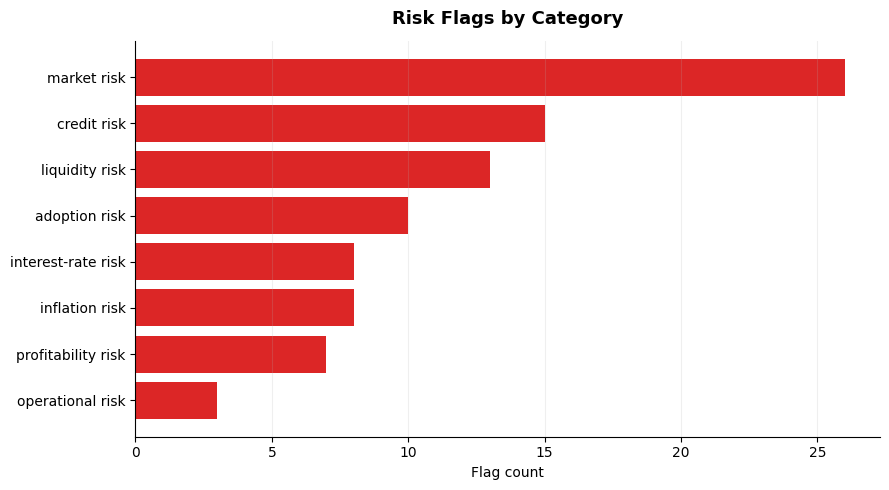

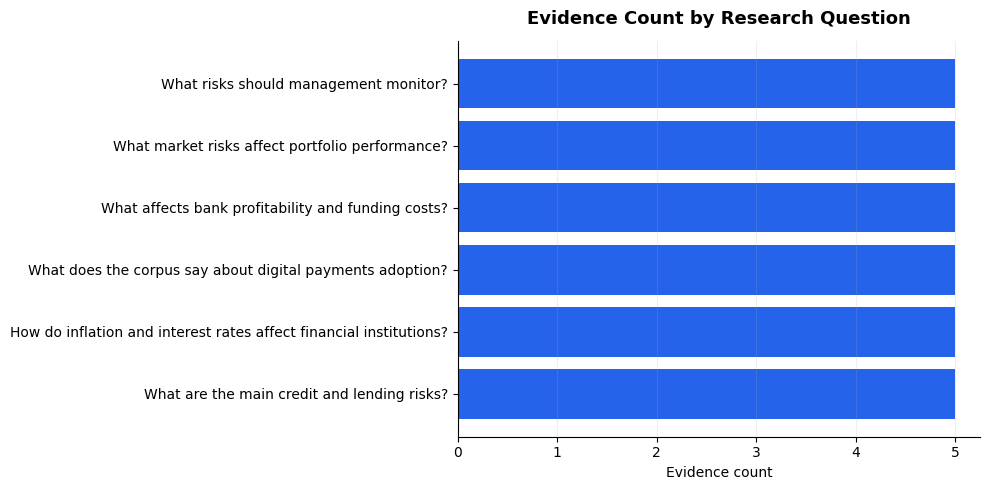

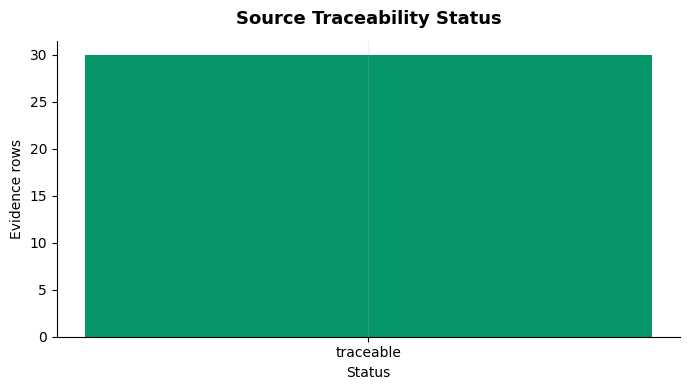

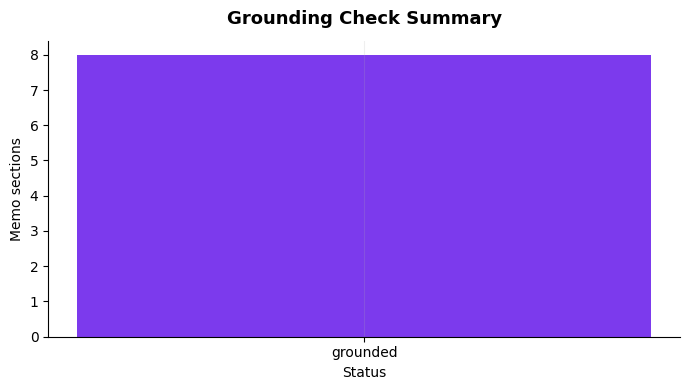

In [13]:
fig = plot_risk_flags_by_category(risk_flags)
fig.savefig(FIGURES_DIR / "risk_flags_by_category.png", dpi=160, bbox_inches="tight")

fig = plot_evidence_count_by_question(coverage_df)
fig.savefig(FIGURES_DIR / "evidence_count_by_question.png", dpi=160, bbox_inches="tight")

fig = plot_source_traceability_status(traceability_df)
fig.savefig(FIGURES_DIR / "source_traceability_status.png", dpi=160, bbox_inches="tight")

fig = plot_grounding_check_summary(grounding_df)
fig.savefig(FIGURES_DIR / "grounding_check_summary.png", dpi=160, bbox_inches="tight")

[
    FIGURES_DIR / "risk_flags_by_category.png",
    FIGURES_DIR / "evidence_count_by_question.png",
    FIGURES_DIR / "source_traceability_status.png",
    FIGURES_DIR / "grounding_check_summary.png",
]

## Limitations

- Documents are synthetic sample notes for a portfolio prototype.
- Retrieval is TF-IDF only and may miss semantic matches.
- Risk flags use keyword rules and can over-tag or under-tag evidence.
- Template-based memo generation improves reproducibility but does not replace analyst writing.
- Grounding checks verify citation presence, not full factual correctness.

## Next steps for Phase 2 polish

- Polish README and career-facing reports.
- Keep limitations visible and honest.
- Optionally add selected figure previews.
- Leave embeddings, paid APIs, and production document parsing as future improvements.